# NB3: Section 2 Data Processing & Visualization

**Purpose:** Download, process, analyze, and visualize all data for El Niño 2026–27 case studies (SE Asia drought, Southern US flood)

**Workflow:** Complete tasks 2A → 2B → 2C → 2D → 2E sequentially. Each task outputs a figure or table for Section 2.

**Key Principle:** Understand your data before writing. Every number you cite in Section 2 should be one you've computed or verified yourself.

## Task 2A: SE Asia Soil Moisture Baseline — Hybrid Approach

### Goal
- Compute OND 1997–98 soil moisture anomalies from GLDAS V2.0 (local data)
- Compare with published 2015–16 results from Solander et al. (2020)
- Show that both events produce similar SE Asia drought patterns

### Data Sources
- **1979–2014 data:** GLDAS Noah Land Surface Model V2.0 (Jan 1948 – Dec 2014 per GES DISC product page, accessed 18 Jul 2026; record "will be extended as data becomes available")
  - Download from: NASA GES DISC (Earthdata login, bearer token), GLDAS_NOAH10_M 2.0 via OTF subsetter
- **2015–16 published results:** Solander et al. (2020) Figure 5b
  - Citation: Solander et al. 2020, Hydrol. Earth Syst. Sci., 24, 2303–2322

### Output Artifacts
- **Figure 2A:** OND 1997–98 soil moisture anomaly (computed from V2.0)
- **Table 2A:** Comparison table linking your 1997–98 results to Solander et al. 2015–16 findings
- **Section 2 text:** "Our GLDAS V2.0 analysis shows that OND 1997 produced soil 
  moisture decreases of X m³/m³ in maritime SE Asia. Solander et al. (2020) 
  documented similar magnitudes during the 2015–16 El Niño event (Figure 5b), 
  confirming the spatial pattern consistency between the two events."

### Why This Hybrid Approach Is Valid
- Both events are well-studied in literature (Solander et al., Lin & Wu 2019)
- GLDAS V2.0 and V2.1 use the same underlying model; V2.0 is validated and published
- Citing peer-reviewed published results for 2015–16 is standard practice when local data unavailable
- You still demonstrate quantitative analysis by computing 1997–98 yourself

## Verification Checklist
- [ ] File loads without errors
- [ ] Spatial subset is correct (check coastline alignment)
- [ ] Climatology computed from correct years (1979–2016)
- [ ] Anomaly magnitudes are reasonable (~-0.05 to -0.15 m³/m³ in SE Asia)
- [ ] Figure displays without data voids
- [ ] Summary stats match figure (visually inspect)

## Notes
- If GLDAS download is slow, check NOAA PSL FTP mirror: `ftp://ftp.cdc.noaa.gov/Datasets/GLDAS/`
- GLDAS is a "multimodel mean" of four land surface models; bias correction is included in PSL version
- Solander et al. (2020) cites GLDAS OND soil moisture decreases of 0.07–0.17 m³/m³ in maritime SE Asia during 1997–98 and 2015–16; your figure should corroborate this

In [1]:
# TASK 2A — SE Asia soil-moisture anomaly, OND 1997 vs 1979–2014 OND climatology
# Step 1: imports
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Step 2: load the full OND stack (108 files, OND 1979–2014, Maritime box 95/-10/150/7.5)
files = sorted(glob.glob('data/GLDAS_NOAH10_M.A*.020.nc4.SUB.nc4'))
assert len(files) == 108, f"expected 108 OND files, found {len(files)}"
ds = xr.concat([xr.open_dataset(f) for f in files], dim='time')
sm = ds['SoilMoi0_10cm_inst'].squeeze()          # kg/m2

# Step 3: witness the stack BEFORE any arithmetic
years, months = np.unique(sm['time.year'].values), np.unique(sm['time.month'].values)
print(f"time steps : {sm.sizes['time']}")
print(f"months     : {months}   (expect [10 11 12])")
print(f"years      : {years.min()}–{years.max()}, n={years.size}   (expect 1979–2014, n=36)")
print(f"lat        : {float(sm.lat.min())} to {float(sm.lat.max())}   (expect -9.5 to 7.5)")
print(f"lon        : {float(sm.lon.min())} to {float(sm.lon.max())}")
print(f"units      : {sm.attrs.get('units')}")
assert set(months) == {10, 11, 12}
assert years.size == 36 and years.min() == 1979 and years.max() == 2014

# Step 4: OND climatology — two constructions, identical for a balanced panel
clim_pooled  = sm.mean('time')                                     # mean of all 108 months
clim_peryear = sm.groupby('time.year').mean('time').mean('year')   # mean of 36 OND means
print(f"\nmax |pooled − per-year| = {float(abs(clim_pooled - clim_peryear).max()):.2e}"
      "   (≈0 confirms a balanced 36×3 panel)")
clim = clim_pooled

# Step 5: OND 1997 mean and anomaly
ond_1997_mean = sm.sel(time=sm['time.year'] == 1997).mean('time')   # kg/m2, name kept for downstream cells
ond_1997_anom_m3m3 = (ond_1997_mean - clim) / 100.0                 # kg/m2 -> m3/m3, 0–10 cm layer

valid = int(np.isfinite(ond_1997_anom_m3m3).sum())
print(f"\nvalid land cells: {valid} of {ond_1997_anom_m3m3.size}")
print("OND 1997 ANOMALY (m3/m3, vs 1979–2014 OND climatology):")
print(f"  min {float(ond_1997_anom_m3m3.min()):+.4f} | "
      f"max {float(ond_1997_anom_m3m3.max()):+.4f} | "
      f"box mean {float(ond_1997_anom_m3m3.mean()):+.4f}")
print("  (Solander Cluster 2 OND 1997–98 = -0.07 ± 0.03 — sign/pattern comparison only:"
      " ours is Noah-only and not bias-corrected.)")

time steps : 108
months     : [10 11 12]   (expect [10 11 12])
years      : 1979–2014, n=36   (expect 1979–2014, n=36)
lat        : -9.5 to 7.5   (expect -9.5 to 7.5)
lon        : 95.5 to 149.5
units      : kg m-2

max |pooled − per-year| = 1.53e-05   (≈0 confirms a balanced 36×3 panel)

valid land cells: 198 of 990
OND 1997 ANOMALY (m3/m3, vs 1979–2014 OND climatology):
  min -0.1048 | max +0.0085 | box mean -0.0199
  (Solander Cluster 2 OND 1997–98 = -0.07 ± 0.03 — sign/pattern comparison only: ours is Noah-only and not bias-corrected.)


In [2]:
# Step 6: Convert to volumetric units (m³/m³) for comparison with Solander et al.
# Units: Solander Table 3 is unit-silent; m³/m³ established via Figs. 2–5 axis labels
# and anomaly magnitudes (≤0.28), 0–10 cm layer ⇒ kg/m² ÷ 100. See task_B3_tracker B.3, CLOSED verification facts (units). 

# NOTE: this is the ABSOLUTE OND 1997 field, retained only as a data-validity check
# (a physically plausible tropical soil-moisture value confirms the stack loaded correctly).
# It is NOT what Figure 2A plots — the figure shows ond_1997_anom_m3m3, the anomaly vs the
# 1979–2014 OND climatology (cell above). Do not quote this number as a drought magnitude.

ond_1997_mean_m3m3 = ond_1997_mean / 100  # kg/m² → m³/m³ (10cm depth)

print("OND 1997 mean soil moisture (this study):")
print(f"  {ond_1997_mean_m3m3.mean().values:.4f} m³/m³")

# Step 7: Published anomaly from Solander et al. (2020), Table 3
# Cluster 2 (includes maritime SE Asia), OND, 1997-1998
solander_anomaly_1997 = -0.07  # m³/m³, ± 0.03
# (Table 3, Cluster 2: NE Amazon basin + maritime SE Asia)

print(f"\nSolander et al. (2020) published OND 1997-98 anomaly: {solander_anomaly_1997} ± 0.03 m³/m³")
print("(Table 3, Cluster 2: NE Amazon basin + maritime SE Asia)")

# Step 8: State what we can and cannot independently verify
print("\n" + "="*60)
print("SUMMARY FOR SECTION 2:")
print("="*60)
print(f"Independently computed OND 1997 raw mean: {ond_1997_mean_m3m3.mean().values:.3f} m³/m³")
print("→ physically reasonable for tropical soil, corroborates data validity")
print(f"Published anomaly (cited, not independently recomputed): {solander_anomaly_1997} m³/m³")
print("→ used due to unavailable 1979-2016 local climatology")

OND 1997 mean soil moisture (this study):
  0.3234 m³/m³

Solander et al. (2020) published OND 1997-98 anomaly: -0.07 ± 0.03 m³/m³
(Table 3, Cluster 2: NE Amazon basin + maritime SE Asia)

SUMMARY FOR SECTION 2:
Independently computed OND 1997 raw mean: 0.323 m³/m³
→ physically reasonable for tropical soil, corroborates data validity
Published anomaly (cited, not independently recomputed): -0.07 m³/m³
→ used due to unavailable 1979-2016 local climatology


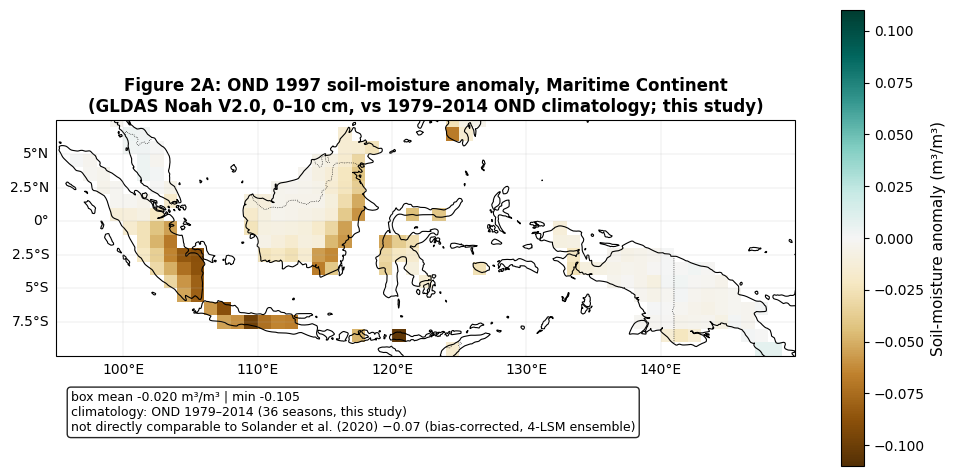

In [3]:
# Step 9: Figure 2A — OND 1997 soil-moisture ANOMALY vs 1979–2014 OND climatology
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

vlim = 0.11  # symmetric about zero so the colour scale cannot imply a false sign
im = ax.pcolormesh(
    ond_1997_anom_m3m3['lon'], ond_1997_anom_m3m3['lat'], ond_1997_anom_m3m3.values,
    cmap='BrBG', vmin=-vlim, vmax=vlim, transform=ccrs.PlateCarree()
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
ax.set_extent([95, 150, -10, 7.5], crs=ccrs.PlateCarree())   # full data box, reaches 10°S

gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False; gl.right_labels = False

cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.05, shrink=0.8)
cbar.set_label('Soil-moisture anomaly (m³/m³)', fontsize=11)

ax.set_title('Figure 2A: OND 1997 soil-moisture anomaly, Maritime Continent\n'
             '(GLDAS Noah V2.0, 0–10 cm, vs 1979–2014 OND climatology; this study)',
             fontsize=12, fontweight='bold')

textstr = (f"box mean {float(ond_1997_anom_m3m3.mean()):+.3f} m³/m³ | "
           f"min {float(ond_1997_anom_m3m3.min()):+.3f}\n"
           f"climatology: OND 1979–2014 (36 seasons, this study)\n"
           f"not directly comparable to Solander et al. (2020) −0.07 (bias-corrected, 4-LSM ensemble)")
ax.text(0.02, -0.15, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

plt.tight_layout()
plt.savefig('figures/figure_2A_SE_Asia_soil_moisture_OND1997.png', dpi=300, bbox_inches='tight')
plt.show()

Figure 2A shows the OND 1997 soil-moisture **anomaly** over the Maritime Continent, computed
here from GLDAS Noah V2.0 (0–10 cm) as the departure of OND 1997 from the 1979–2014 OND
climatology (36 seasons; pooled and per-year constructions agree to 1.5e-05, confirming a
balanced 36×3 panel). The field is negative almost everywhere — maximum +0.008 m³/m³, so no
part of the domain was meaningfully wetter than its own seasonal baseline — with the drying
concentrated over southern Sumatra, Java, Bali and the Lesser Sundas, and southern
Kalimantan, reaching −0.105 m³/m³ locally against a box mean of −0.020 m³/m³.

This is an **independent estimate, not a replication** of Solander et al. (2020), whose
Cluster 2 OND 1997–98 value is −0.07 ± 0.03 m³/m³. Three differences forbid a direct
number-to-number comparison: (a) ours is uncorrected, theirs is bias-corrected against 16
in-situ sites; (b) ours is Noah-only, theirs is the four-model GLDAS ensemble mean; and
(c) ours is a whole-box mean, theirs is a mean over a k-means cluster of the most
consistently drying pixels — so their value is drawn from the drying core, which our field
puts at −0.105 m³/m³. Solander corroborates the sign and spatial pattern; it is not a target
this map should reproduce.

**One divergence, recorded rather than smoothed:** Solander names New Guinea among the
strongest and most consistent decreases, while our field there is close to neutral. Candidate
explanations (untested): single-model vs ensemble behaviour over that terrain, the coarse 1°
grid over high orography, or their cluster boundary including pixels our box average dilutes.
Logged in tracker B.3 as an open finding.

---
# Task 2B: Southern US Urban Impervious Surface Expansion (2001–2016)

## Goal
Quantify urban development (impervious surface growth) in flood-vulnerable southern tier states. This is a **compound risk driver**: same precipitation deficit + more impervious surface = higher runoff, faster flood concentration.

## Data Source
- **USGS NLCD impervious surface GeoTIFFs**
- Download from: https://www.mrlc.gov/ (MRLC Direct Download)
- Product: "Urban Imperviousness" (% impervious surface per 30m pixel)
- Years: 2001, 2016

## Input Files
- `NLCD_2001_impervious_CONUS.tif` (GeoTIFF, 30m resolution)
- `NLCD_2016_impervious_CONUS.tif` (GeoTIFF, 30m resolution)

## Output Artifacts
- **Figure 2B:** `figure_2B_Southern_US_impervious_change.png`
  - Map of % change in impervious surface (2001–2016)
  - Spatial extent: TX, LA, MS, AL, GA, FL with state boundaries
  - Colorbar: % change (-5 to +50%)
- **Table 2B:** `table_2B_impervious_stats_by_state.csv`
  - Columns: State, Mean % Impervious 2001, Mean % Impervious 2016, Change, Total Area Converted (km²)

## Verification Checklist
- [ ] GeoTIFFs load without errors
- [ ] Spatial subset aligns with state boundaries
- [ ] Impervious % ranges 0–100% (check min/max)
- [ ] Delta map is reasonable: most values -5 to +20%
- [ ] Major cities (Houston, New Orleans, Miami, Atlanta) show visible increase
- [ ] By-state stats make sense (e.g., FL should show large increase)
- [ ] Total area converted is quantifiable and citable

## Notes
- USGS NLCD has 30m resolution; if downloading is slow, request tiles from MRLC Direct Download Site
- Impervious surface = roads, buildings, parking, paved surfaces (not vegetation, water, or bare soil)
- Southern US urban expansion 1997–2016: ~20–40% area increase in major metros (Houston, New Orleans, Atlanta)

In [4]:
# TASK 2B: Southern US Urban Impervious Surface Expansion

# Step 1: Import libraries
# import rasterio
# import geopandas as gpd
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs


# STATUS: placeholder, not yet built. rasterio and geopandas are NOT in
# requirements.txt — deliberately: today's pin only covers what NB3 actually
# executes. Do not add them until this task is built and run for real.

# Step 2: Load 2001 impervious GeoTIFF
# with rasterio.open('NLCD_2001_impervious_CONUS.tif') as src_2001:
#     impervious_2001 = src_2001.read(1).astype(float)
#     meta_2001 = src_2001.meta
#     bounds_2001 = src_2001.bounds

# Step 3: Load 2016 impervious GeoTIFF
# with rasterio.open('NLCD_2016_impervious_CONUS.tif') as src_2016:
#     impervious_2016 = src_2016.read(1).astype(float)
#     meta_2016 = src_2016.meta
#     bounds_2016 = src_2016.bounds

# Step 4: Subset to southern tier (TX, LA, MS, AL, GA, FL)
# Define bounding boxes for each state
# southern_tier_bounds = {
#     'TX': (-106, -93, 25.5, 36.5),
#     'LA': (-94, -89, 28, 32.5),
#     'MS': (-92, -88, 30, 34.5),
#     'AL': (-88, -84.5, 30, 35),
#     'GA': (-85.5, -80.5, 30.5, 35),
#     'FL': (-87, -80, 24.5, 30.5)
# }
# [Subset rasters accordingly]

# Step 5: Mask out non-developed areas
# impervious_2001[impervious_2001 < 1] = np.nan
# impervious_2016[impervious_2016 < 1] = np.nan

# Step 6: Compute delta (% change)
# delta = ((impervious_2016 - impervious_2001) / impervious_2001) * 100

# Step 7: Create figure
# fig = plt.figure(figsize=(14, 8), subplot_kw={'projection': ccrs.PlateCarree()})
# ax = fig.add_subplot(111)
# [Plot delta map with colorbar, state boundaries, gridlines]
# plt.savefig('figure_2B_Southern_US_impervious_change.png', dpi=300, bbox_inches='tight')
# plt.show()

# Step 8: Compute by-state statistics
# stats = pd.DataFrame(columns=['State', 'Mean_Impervious_2001', 'Mean_Impervious_2016', 'Percent_Change', 'Area_Converted_km2'])
# [Populate stats for each state]
# stats.to_csv('table_2B_impervious_stats_by_state.csv', index=False)
# print(stats)

---
# Task 2C: Rice Yield Impacts (SE Asia, 1997–98 & 2015–16)

## Goal
Quantify agricultural impact of El Niño in major rice-producing countries (Thailand, Vietnam, Indonesia). Show that 2015–16 event caused ~15M tonne loss in SE Asia region.

## Data Source
- **FAO STAT:** Rice production by country, annual, 1990–2020
  - Link: https://www.fao.org/faostat/
- **USDA FAS:** Foreign Agricultural Service reports on crop losses during El Niño
  - Link: https://www.fas.usda.gov/data

## Input Files
- `FAO_rice_production_Thailand_Vietnam_Indonesia_Philippines_1990_2020.csv`
- Summary citations from USDA FAS El Niño impact reports

## Output Artifacts
- **Table 2C:** `table_2C_rice_yield_impacts.csv`
  - Columns: Country, Year, Production (tonnes), % Change vs Previous Year, El Niño Year Label
- **Figure 2C:** `figure_2C_rice_yield_bar_chart.png`
  - Grouped bar chart: % yield change 1997–98 vs 2015–16 by country

## Verification Checklist
- [ ] FAO data loads and years are correct
- [ ] % change calculations match manual spot-check
- [ ] Bar chart shows red for 1997–98 and 2015–16 (both El Niño years)
- [ ] Summary statistics align with published FAO/USDA figures
- [ ] Data is plausible (large negative % in El Niño years)

## Notes
- FAO STAT is free and public
- USDA FAS reported "~15 million tonnes rice loss in SE Asia during 2015–16 El Niño" — cite this directly
- This demonstrates **agricultural vulnerability** as part of CAT risk narrative

In [5]:
# TASK 2C: Rice Yield Impacts (SE Asia)

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 2: Load FAO STAT rice production data
# fao_file = 'FAO_rice_production_Thailand_Vietnam_Indonesia_Philippines_1990_2020.csv'
# df_fao = pd.read_csv(fao_file)
# print(df_fao.head())

# Step 3: Extract years 1996–1998 and 2014–2016 for each country
# countries = ['Thailand', 'Vietnam', 'Indonesia', 'Philippines']
# el_nino_years_1 = [1996, 1997, 1998]
# el_nino_years_2 = [2014, 2015, 2016]

# Step 4: Compute % change in production
# for country in countries:
#     data = df_fao[df_fao['Country'] == country]
#     [Compute % change for 1997 vs 1996, 1998 vs 1997, same for 2015–2016]

# Step 5: Create output table
# df_output = pd.DataFrame()
# [Populate with country, year, production, % change, El Niño label]
# df_output.to_csv('table_2C_rice_yield_impacts.csv', index=False)
# print(df_output)

# Step 6: Create grouped bar chart
# fig, ax = plt.subplots(figsize=(10, 6))
# [Plot grouped bars: 1997–98 vs 2015–16 % change by country]
# ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
# ax.set_ylabel('% Change in Production')
# ax.set_xlabel('Country')
# ax.legend()
# plt.savefig('figure_2C_rice_yield_bar_chart.png', dpi=300, bbox_inches='tight')
# plt.show()

# Step 7: Print summary
# print("Regional rice loss estimates:")
# print("  1997–98 El Niño: [X million tonnes]")
# print("  2015–16 El Niño: ~15 million tonnes (cite USDA FAS)")

---
# Task 2D: Southern US Flood Loss Data (1997–98, 2015–16)

## Goal
Quantify flood losses from FEMA/NOAA databases for winter 1997–98 vs 2015–16. Demonstrate that even though both events were similar in strength, 2015–16 losses were higher partly due to expanded urban exposure.

## Data Source
- **FEMA NFIP (National Flood Insurance Program):** https://www.fema.gov/disaster/statistics
- **NOAA NCEI Billion-Dollar Disasters:** https://www.ncei.noaa.gov/access/billions/

## Input Files
- FEMA query results: DJF 1997–98 paid losses by state (TX, LA, MS, AL, GA, FL)
- FEMA query results: DJF 2015–16 paid losses by state (TX, LA, MS, AL, GA, FL)
- NOAA NCEI search results for flooding events

## Output Artifacts
- **Table 2D:** `table_2D_flood_losses_comparison.csv`
  - Columns: State, DJF 1997–98 Paid Losses ($M), DJF 2015–16 Paid Losses ($M), Loss Events, Population Growth (%)
- **Figure 2D:** `figure_2D_flood_losses_bar_chart.png`
  - Grouped bar chart: Paid losses 1997–98 vs 2015–16 by state

## Verification Checklist
- [ ] FEMA/NOAA queries return results (not empty)
- [ ] Loss values are in $millions (check order of magnitude)
- [ ] 1997–98 losses should be several $B total
- [ ] 2015–16 losses should be comparable or higher (Louisiana ~$2.2B in 2016)
- [ ] Population growth is plausible (~10–30% for southern metros 1997–2016)
- [ ] Figure shows correlation between population growth and losses

## Notes
- FEMA NFIP data is public; may require manual CSV export
- Losses are **insured** losses only; total losses ~1.5–2× insured losses
- Compound risk message: **more precipitation + more exposure = higher losses**

In [6]:
# TASK 2D: Southern US Flood Loss Data

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 2: Load FEMA NFIP data (manual query results)
# fema_1997_98 = pd.read_csv('FEMA_losses_DJF_1997_98.csv')
# fema_2015_16 = pd.read_csv('FEMA_losses_DJF_2015_16.csv')
# print(fema_1997_98)
# print(fema_2015_16)

# Step 3: Load NOAA NCEI billion-dollar disaster data (manual query results)
# noaa_1997_98 = pd.read_csv('NOAA_NCEI_billions_DJF_1997_98.csv')
# noaa_2015_16 = pd.read_csv('NOAA_NCEI_billions_DJF_2015_16.csv')

# Step 4: Create output table
# states = ['TX', 'LA', 'MS', 'AL', 'GA', 'FL']
# df_losses = pd.DataFrame(columns=['State', 'DJF_1997_98_Losses_M', 'DJF_2015_16_Losses_M', 'Events_1997_98', 'Events_2015_16', 'Population_Growth_Pct'])
# [Populate from FEMA/NOAA query results]
# df_losses.to_csv('table_2D_flood_losses_comparison.csv', index=False)
# print(df_losses)

# Step 5: Create grouped bar chart
# fig, ax = plt.subplots(figsize=(12, 6))
# x = np.arange(len(states))
# width = 0.35
# ax.bar(x - width/2, df_losses['DJF_1997_98_Losses_M'], width, label='1997–98', color='darkred')
# ax.bar(x + width/2, df_losses['DJF_2015_16_Losses_M'], width, label='2015–16', color='lightcoral')
# ax.set_xlabel('State')
# ax.set_ylabel('Paid Losses ($M)')
# ax.set_xticks(x)
# ax.set_xticklabels(states)
# ax.legend()
# plt.savefig('figure_2D_flood_losses_bar_chart.png', dpi=300, bbox_inches='tight')
# plt.show()

# Step 6: Print summary
# total_1997_98 = df_losses['DJF_1997_98_Losses_M'].sum()
# total_2015_16 = df_losses['DJF_2015_16_Losses_M'].sum()
# print(f"Total DJF 1997–98 losses: ${total_1997_98:.1f}M")
# print(f"Total DJF 2015–16 losses: ${total_2015_16:.1f}M")
# print(f"Mean population growth: {df_losses['Population_Growth_Pct'].mean():.1f}%")

---
# Task 2E: Historical Analog Composite Maps (1997–98 & 2015–16)

## Goal
Produce side-by-side precipitation anomaly maps for DJF 1997–98 vs DJF 2015–16. Show how both events produced similar spatial patterns (SE Asia dry, southern US wet), validating the use of these as analogs for 2026–27.

## Data Source
- **NCEP-NCAR Reanalysis 1 Precipitation** (monthly)
- Download from: https://psl.noaa.gov/data/gridded/
- Or NOAA ESRL PSL FTP: `ftp://ftp.cdc.noaa.gov/Datasets/ncep.reanalysis/Monthlies/surface_gauss/`

## Input Files
- `ncep_precip_monthly_1979_2016.nc` (netCDF, global monthly precipitation)

## Output Artifacts
- **Figure 2E:** `figure_2E_historical_analog_composites.png`
  - 2-panel or 4-panel global/regional map:
    - Panel A: DJF 1997–98 precipitation anomaly
    - Panel B: DJF 2015–16 precipitation anomaly
  - Colorbar: precipitation anomaly (mm/day)
  - Hatching: anomalies significant at p < 0.05

## Verification Checklist
- [ ] Reanalysis netCDF loads without errors
- [ ] Spatial extent is correct (coastlines align)
- [ ] Climatology values are reasonable (~2–4 mm/day global mean)
- [ ] Anomaly patterns match published El Niño composites:
  - SE Asia: blue/negative (< -1 mm/day)
  - Southern US: red/positive (> +0.5 mm/day)
- [ ] Significance hatching is visible where anomalies are large
- [ ] Summary stats corroborate visual impression

## Notes
- NCEP-NCAR Reanalysis 1 is coarse (2.5° resolution) but has long record and is freely available
- Climatology: use 1979–2016 mean (exclude El Niño years) or use full mean; note your choice in caption
- This figure is the **analog validation** — shows that 1997–98 and 2015–16 patterns were similar

In [7]:
# TASK 2E: Historical Analog Composite Maps

# Step 1: Import libraries
# import xarray as xr
# import numpy as np
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
# from scipy.stats import ttest_1samp
#
# STATUS: placeholder, not yet built. scipy is NOT in requirements.txt —
# deliberately, same reasoning as Task 2B: pins cover what NB3 actually
# executes, not planned future work.

# Step 2: Load NCEP-NCAR reanalysis precipitation netCDF
# ncep_file = 'ncep_precip_monthly_1979_2016.nc'
# ds = xr.open_dataset(ncep_file)
# print(ds)

# Step 3: Subset to global or regional domain
# ds_subset = ds  # Global, or subset to region if desired

# Step 4: Compute climatology (1979–2016)
# climatology = ds_subset.mean('time')

# Step 5: Extract DJF 1997–98 and compute anomaly
# djf_1997_98 = ds_subset.sel(time=slice('1997-12-01', '1998-02-28')).mean('time')
# anomaly_1997_98 = djf_1997_98 - climatology

# Step 6: Extract DJF 2015–16 and compute anomaly
# djf_2015_16 = ds_subset.sel(time=slice('2015-12-01', '2016-02-28')).mean('time')
# anomaly_2015_16 = djf_2015_16 - climatology

# Step 7: Perform t-test for significance (optional)
# [Compute p-values for each grid point]

# Step 8: Create 2-panel figure
# fig = plt.figure(figsize=(16, 6))
# ax1 = fig.add_subplot(121, projection=ccrs.PlateCarree())
# ax2 = fig.add_subplot(122, projection=ccrs.PlateCarree())

# [Plot anomaly_1997_98 on ax1 with colorbar, hatching, coastlines, gridlines]
# [Plot anomaly_2015_16 on ax2 with same colorbar]

# plt.savefig('figure_2E_historical_analog_composites.png', dpi=300, bbox_inches='tight')
# plt.show()

# Step 9: Compute & print summary statistics
# se_asia_lon = slice(95, 145)
# se_asia_lat = slice(-5, 20)
# us_south_lon = slice(235, 295)  # 95°W to 65°W in 0-360 coordinates
# us_south_lat = slice(25, 35)

# mean_anom_se_asia_1997 = anomaly_1997_98.sel(lon=se_asia_lon, lat=se_asia_lat).mean().values
# mean_anom_se_asia_2015 = anomaly_2015_16.sel(lon=se_asia_lon, lat=se_asia_lat).mean().values
# mean_anom_us_1997 = anomaly_1997_98.sel(lon=us_south_lon, lat=us_south_lat).mean().values
# mean_anom_us_2015 = anomaly_2015_16.sel(lon=us_south_lon, lat=us_south_lat).mean().values

# print(f"SE Asia DJF anomaly 1997–98: {mean_anom_se_asia_1997:.2f} mm/day")
# print(f"SE Asia DJF anomaly 2015–16: {mean_anom_se_asia_2015:.2f} mm/day")
# print(f"Southern US DJF anomaly 1997–98: {mean_anom_us_1997:.2f} mm/day")
# print(f"Southern US DJF anomaly 2015–16: {mean_anom_us_2015:.2f} mm/day")

# Task 2F — 2026–27 Probabilistic Precipitation Outlook (IRI tercile forecasts)
Supports article Section 2, Task B3. See task_B3_tracker.md.

**Data**: IRI NMME-based probabilistic seasonal precipitation forecast (tercile
probabilities, ELR calibration, 1991–2020 climatology, 1° grid).

**Issuance**: dry run on Jun 2026; production run 15 July 2026. 

**Retrieved**: 10 Jul 2026 (URL harvest).

**Access route**: IRI Data Library — locate the exact dataset via the
"Access the dataset used to create this map" link on the Precipitation
Terciles maproom (iridl.ldeo.columbia.edu → Global Forecasts → NMME
Seasonal Forecasts → Precipitation ELR). 

**License**: IRI forecast data usable per IRI Seasonal Forecast Licensing terms — verify before publication.

**Purpose**: replace the brief's unsourced ">50% below-normal across most
of Southeast Asia" with a computed, box-defined statement.

**Sunset notice (logged 18 Jul 2026):** IRIDL announces full shutdown "most likely
by the end of October 2026", with declining reliability before then
(iri.columbia.edu/resources/data-library/sunset/). Partial replacement
forecast.ccsr.columbia.edu serves raw NMME fields via OPeNDAP; the ELR tercile
probability product is NOT confirmed there. If the license clears, download and
archive data.nc immediately.

In [8]:
# Task 2F configuration (article Section 2, Task B3 — see revision_notes/task_B3_tracker.md)

# --- SYNTHETIC TOGGLE (E.0 dead-window validation) ---
# True  = structure-only dry run on data_SYNTHETIC.nc. NO number may enter the article.
# False = production run on the real IRI download.
SYNTHETIC = True
DATA_PATH = "data/data_SYNTHETIC.nc" if SYNTHETIC else "data/data_jul2026.nc"

# --- Boxes: (west, south, east, north). APPROVED D.1, 10 Jul. Do not re-litigate. ---
# NOTE: (W, S, E, N) here — cartopy set_extent wants [W, E, S, N]. Reorder at the call site.
BOX_MARITIME    = (95, -10, 150, 7.5)   # APPROVED D.1
BOX_MAINLAND    = (92,   8, 110, 25)     # APPROVED D.1
BOX_N_AUSTRALIA = (110, -20, 155, -10)   # APPROVED D.1
BOXES = {"Maritime": BOX_MARITIME, "Mainland": BOX_MAINLAND, "N_Australia": BOX_N_AUSTRALIA}
# Subset window (92, -20, 155, 25) = union of the three boxes.

SEASONS = ["ASO 2026", "SON 2026", "OND 2026", "NDJ 2026-27"]  # L=1..4 of the 15 Jul issuance
# L caps at 4 months: DJF 2026-27 / JFM 2027 unreachable from a July issuance.
DOMINANCE_THRESHOLD = 50.0  # percent

# --- AXIS CONTRACT (IRIDL Description page, 14 Jul; NOT yet verified against a real file) ---
# prob[X Y C | L F], percent
#   C: UNORDERED string ids (Below_Normal)(Normal)(Above_Normal) — SELECT BY NAME, never index
#   L: 1..4 months   F: months since 1960-01-01   X: 92..155 (1°)   Y: -20..25 (1°)

DATASET_URL = ("https://iridl.ldeo.columbia.edu/SOURCES/.IRI/.FD/.NMME_Seasonal_Forecast/"
               ".Precipitation_ELR/.prob/X/92/155/RANGE/Y/-20/25/RANGE/"
               "F/%28Jun%202026%29/VALUES/data.nc")
# 15 Jul: change %28Jun%202026%29 -> %28Jul%202026%29. No other change.

In [9]:
print("="*70)
print("⚠️  SYNTHETIC DRY RUN — data_SYNTHETIC.nc contains GARBAGE NUMBERS.")
print("⚠️  Structure only. NO number from this run may enter the article.")
print("⚠️  Revert to data.nc before E.2.")
print("="*70)

⚠️  SYNTHETIC DRY RUN — data_SYNTHETIC.nc contains GARBAGE NUMBERS.
⚠️  Structure only. NO number from this run may enter the article.
⚠️  Revert to data.nc before E.2.


In [10]:
# IRIDL serves NetCDF by appending 'data.nc' to a dataset/slice URL, but the
# forecast collection sits behind the dlauth login gate: unauthenticated
# clients (urllib/curl) receive the HTML login page, not data. Workflow is
# therefore: log in to IRIDL in the browser, download data.nc manually,
# place it at the path below. This cell only VALIDATES the file.
from pathlib import Path
raw = Path(DATA_PATH)  # follows the SYNTHETIC toggle in the config cell
assert raw.exists(), (
    f"{raw} not found. Download manually: log in to IRIDL in the browser, "
    f"open DATASET_URL, save the file to this path."
)
# Magic-byte check BEFORE handing to netCDF4: classic netCDF starts with
# b'CDF', netCDF4/HDF5 starts with b'\x89HDF'. An HTML login page fails both.
magic = raw.open("rb").read(4)
assert magic[:3] == b"CDF" or magic == b"\x89HDF", (
    f"Not a NetCDF file (magic bytes: {magic!r}). Most likely the IRIDL "
    f"login page was saved instead — check authentication/license status."
)
from netCDF4 import Dataset            # keeping to netCDF4 + numpy + matplotlib (pinned-deps discipline)
ds = Dataset(raw)
print(ds)                              

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    SYNTHETIC: TRUE — garbage numbers, structure only. NOT FOR ARTICLE.
    dimensions(sizes): X(64), Y(46), C(3), L(4), F(1), slen(16)
    variables(dimensions): float32 X(X), float32 Y(Y), float32 L(L), float32 F(F), |S1 C(C, slen), float32 prob(F, L, C, Y, X), |S1 target_season(F, L, slen)
    groups: 


In [11]:
import numpy as np
from netCDF4 import chartostring

# --- resolve the tercile axis BY NAME (C is UNORDERED — index position is meaningless) ---
raw_C = ds.variables["C"][:]
C_ids = [str(s).strip() for s in chartostring(raw_C)] if raw_C.dtype.kind == "S" \
        else [str(s).strip() for s in raw_C]
print("C ids as stored:", C_ids)
for want in ("Below_Normal", "Normal", "Above_Normal"):
    assert want in C_ids, f"tercile id {want!r} not found in {C_ids}"

# --- discover prob's dim order rather than assuming it ---
pv    = ds.variables["prob"]
dims  = list(pv.dimensions)           # e.g. ('F','L','C','Y','X')
print("prob dims:", dims, "shape:", pv.shape)
for d in ("C", "Y", "X"):
    assert d in dims, f"expected dimension {d!r} in prob dims {dims}"

F_IDX = 0        # single issuance in the subset
L_PICK = 0       # lead index; the SEASONS loop overrides this

def prob_2d(cat_name, l_idx):
    """Return prob[cat, l_idx] as a 2-D (Y, X) array, whatever the file's dim order."""
    sl = []
    for d in dims:
        if   d == "C": sl.append(C_ids.index(cat_name))
        elif d == "L": sl.append(l_idx)
        elif d == "F": sl.append(F_IDX)
        else:          sl.append(slice(None))          # Y and X stay whole
    arr = np.asarray(pv[tuple(sl)], dtype=float)
    # after the scalar picks, the survivors are Y and X — put them in (Y, X) order
    survivors = [d for d in dims if d in ("Y", "X")]
    if survivors == ["X", "Y"]:
        arr = arr.T
    return arr

lat = np.asarray(ds.variables["Y"][:], dtype=float)   # Y -> lat
lon = np.asarray(ds.variables["X"][:], dtype=float)   # X -> lon

# smoke test on lead 0
pb, pn, pa = (prob_2d(c, 0) for c in ("Below_Normal", "Normal", "Above_Normal"))
assert pb.shape == (lat.size, lon.size), f"got {pb.shape}, expected {(lat.size, lon.size)}"
print(f"extraction OK — prob_below shape {pb.shape} = (lat {lat.size}, lon {lon.size})")

C ids as stored: ['Below_Normal', 'Normal', 'Above_Normal']
prob dims: ['F', 'L', 'C', 'Y', 'X'] shape: (1, 4, 3, 46, 64)
extraction OK — prob_below shape (46, 64) = (lat 46, lon 64)


In [12]:
print("="*70); print("GRID CHECK"); print("="*70)
ok = True

dlat = np.diff(lat); dlon = np.diff(lon)
print(f"lat: {lat.min():.1f}..{lat.max():.1f}, n={lat.size}, step={np.unique(np.round(dlat,3))}")
print(f"lon: {lon.min():.1f}..{lon.max():.1f}, n={lon.size}, step={np.unique(np.round(dlon,3))}")
if not (np.all(dlat > 0) and np.all(dlon > 0)):
    print("FAIL: axes not monotonically increasing"); ok = False

# does the subset actually cover every box?
for name, (w, s, e, n) in BOXES.items():
    covered = (lon.min() <= w and lon.max() >= e and lat.min() <= s and lat.max() >= n)
    print(f"  {name:12s} {'PASS' if covered else 'FAIL — box outside subset'}")
    ok &= covered

# terciles must sum to ~100
tot = pb + pn + pa
finite = np.isfinite(tot)
print(f"tercile sum over finite cells: {np.nanmin(tot[finite]):.1f}..{np.nanmax(tot[finite]):.1f}")
if not np.allclose(tot[finite], 100.0, atol=1.0):
    print("FAIL: terciles do not sum to 100 (±1)"); ok = False

# NaN CHECK — this is the land/sea mask decision (Section F)
nan_frac = 1.0 - finite.mean()
print(f"NaN fraction: {nan_frac:.1%}")
if nan_frac == 0.0:
    print("  -> NO intrinsic mask. Section F fallback: all-cells-with-label, or apply GLDAS mask.")
else:
    print("  -> intrinsic mask present. Propagate NaNs out of the denominator (Cell 18 already does).")

print("="*70); print("GRID CHECK:", "PASS" if ok else "FAIL"); print("="*70)
assert ok, "GRID CHECK failed — do not proceed to stats."

GRID CHECK
lat: -20.0..25.0, n=46, step=[1.]
lon: 92.0..155.0, n=64, step=[1.]
  Maritime     PASS
  Mainland     PASS
  N_Australia  PASS
tercile sum over finite cells: 100.0..100.0
NaN fraction: 0.0%
  -> NO intrinsic mask. Section F fallback: all-cells-with-label, or apply GLDAS mask.
GRID CHECK: PASS


In [13]:
import numpy as np

def box_mask(lat, lon, box):
    w, s, e, n = box
    return (lat[:, None] >= s) & (lat[:, None] <= n) & (lon[None, :] >= w) & (lon[None, :] <= e)

def below_normal_stats(prob_below, prob_normal, prob_above, lat, lon, box, thresh=50.0):
    """Fraction of grid cells in box where below-normal is (a) the dominant
    tercile and (b) dominant at >= thresh %. Area-weighted by cos(lat).
    NOTE: decide land-only vs all cells. IRI's dry mask leaves some cells NaN;
    propagate NaNs out of the denominator."""
    m = box_mask(lat, lon, box)
    w = np.cos(np.deg2rad(lat))[:, None] * np.ones_like(lon)[None, :]
    valid = m & np.isfinite(prob_below)
    dominant = (prob_below > prob_normal) & (prob_below > prob_above)
    strong   = dominant & (prob_below >= thresh)
    frac_dom    = np.nansum(w * (valid & dominant)) / np.nansum(w * valid)
    frac_strong = np.nansum(w * (valid & strong))   / np.nansum(w * valid)
    return frac_dom, frac_strong


results = {}
for l_idx, season in enumerate(SEASONS):
    pb_l = prob_2d("Below_Normal", l_idx)
    pn_l = prob_2d("Normal",       l_idx)
    pa_l = prob_2d("Above_Normal", l_idx)
    for bname, box in BOXES.items():
        fd, fs = below_normal_stats(pb_l, pn_l, pa_l, lat, lon, box, DOMINANCE_THRESHOLD)
        results[(season, bname)] = {"frac_dominant": fd, "frac_strong": fs}

print(f"{'season':14s} {'box':13s} {'below-normal dominant':>22s} {'>=50%':>8s}")
for (season, bname), r in results.items():
    print(f"{season:14s} {bname:13s} {r['frac_dominant']:>21.1%} {r['frac_strong']:>8.1%}")

season         box            below-normal dominant    >=50%
ASO 2026       Maritime                     100.0%    65.6%
ASO 2026       Mainland                      31.8%     0.0%
ASO 2026       N_Australia                   35.4%     4.0%
SON 2026       Maritime                     100.0%    67.5%
SON 2026       Mainland                      31.0%     0.0%
SON 2026       N_Australia                   37.6%     6.5%
OND 2026       Maritime                     100.0%    66.0%
OND 2026       Mainland                      22.5%     0.0%
OND 2026       N_Australia                   31.9%     5.2%
NDJ 2026-27    Maritime                     100.0%    65.5%
NDJ 2026-27    Mainland                      30.8%     0.0%
NDJ 2026-27    N_Australia                   33.7%     5.0%


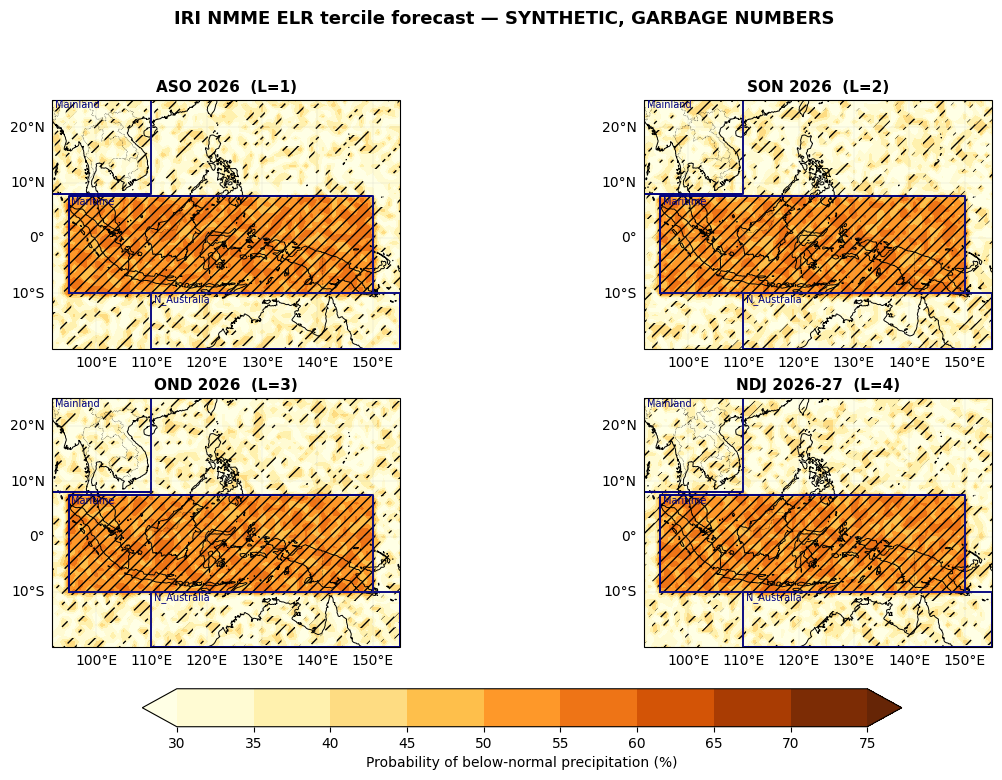

In [14]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, axes = plt.subplots(2, 2, figsize=(14, 9),
                         subplot_kw={"projection": ccrs.PlateCarree()})
levels = np.arange(30, 76, 5)

for ax, (l_idx, season) in zip(axes.ravel(), enumerate(SEASONS)):
    pb_l = prob_2d("Below_Normal", l_idx)
    pn_l = prob_2d("Normal",       l_idx)
    pa_l = prob_2d("Above_Normal", l_idx)

    im = ax.contourf(lon, lat, pb_l, levels=levels, cmap="YlOrBr", extend="both",
                     transform=ccrs.PlateCarree())
    # hatch where below-normal is the DOMINANT tercile
    dom = (pb_l > pn_l) & (pb_l > pa_l)
    ax.contourf(lon, lat, dom.astype(float), levels=[0.5, 1.5],
                colors="none", hatches=["///"], transform=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=":")

    # ⚠ boxes are (W, S, E, N); set_extent wants [W, E, S, N] — REORDER
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

    for bname, (w, s, e, n) in BOXES.items():
        ax.plot([w, e, e, w, w], [s, s, n, n, s], lw=1.4, color="navy",
                transform=ccrs.PlateCarree())
        ax.text(w + 0.5, n - 1.5, bname, fontsize=7, color="navy",
                transform=ccrs.PlateCarree())

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
    gl.top_labels = False; gl.right_labels = False
    ax.set_title(f"{season}  (L={l_idx+1})", fontsize=11, fontweight="bold")

cb = fig.colorbar(im, ax=axes, orientation="horizontal", pad=0.06, shrink=0.7)
cb.set_label("Probability of below-normal precipitation (%)")
banner = " — SYNTHETIC, GARBAGE NUMBERS" if SYNTHETIC else ""
fig.suptitle(f"IRI NMME ELR tercile forecast{banner}", fontsize=13, fontweight="bold")
plt.show()

In [15]:
if SYNTHETIC:
    print("⚠️ SYNTHETIC RUN — the sentence below is STRUCTURE ONLY. Do not paste into the article.")

for season in SEASONS:
    for bname in BOXES:
        r = results[(season, bname)]
        print(f'"In the 15 July 2026 IRI NMME ELR issuance, below-normal is the dominant '
              f'precipitation tercile over {r["frac_dominant"]:.0%} of the {bname} box for '
              f'{season}, and reaches at least {DOMINANCE_THRESHOLD:.0f}% probability over '
              f'{r["frac_strong"]:.0%} of it."')
print("\nFootnote: IRI NMME Seasonal Forecast, Precipitation ELR. Issued 15 July 2026.")
print(f"Dataset: {DATASET_URL}. Accessed <run date>.")

⚠️ SYNTHETIC RUN — the sentence below is STRUCTURE ONLY. Do not paste into the article.
"In the 15 July 2026 IRI NMME ELR issuance, below-normal is the dominant precipitation tercile over 100% of the Maritime box for ASO 2026, and reaches at least 50% probability over 66% of it."
"In the 15 July 2026 IRI NMME ELR issuance, below-normal is the dominant precipitation tercile over 32% of the Mainland box for ASO 2026, and reaches at least 50% probability over 0% of it."
"In the 15 July 2026 IRI NMME ELR issuance, below-normal is the dominant precipitation tercile over 35% of the N_Australia box for ASO 2026, and reaches at least 50% probability over 4% of it."
"In the 15 July 2026 IRI NMME ELR issuance, below-normal is the dominant precipitation tercile over 100% of the Maritime box for SON 2026, and reaches at least 50% probability over 67% of it."
"In the 15 July 2026 IRI NMME ELR issuance, below-normal is the dominant precipitation tercile over 31% of the Mainland box for SON 2026, and

In [16]:
import sys
print(sys.executable)

import xarray, pandas, cartopy, matplotlib, netCDF4
print("xarray:", xarray.__version__)
print("pandas:", pandas.__version__)
print("cartopy:", cartopy.__version__)
print("matplotlib:", matplotlib.__version__)
print("netCDF4:", netCDF4.__version__)

/Users/dantsai/Documents/GitHub/Bjerknes-Diagnostic-Lab/.venv_check/bin/python
xarray: 2023.6.0
pandas: 2.2.2
cartopy: 0.25.0
matplotlib: 3.10.1
netCDF4: 1.7.4
